In [1]:
import scipy as sp
import torch 
from scipy import integrate
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from bokeh.plotting import figure, show
import pandas as pd
from bokeh.io import curdoc,output_notebook,export_png
from bokeh.layouts import column,gridplot
#from print_versions import print_versions
from sklearn.metrics import r2_score
from seaborn import clustermap
from bokeh.models import Band, ColumnDataSource
import pandas as pd
TOOLS="hover,crosshair,pan,wheel_zoom,zoom_in,zoom_out,box_zoom,undo,redo,reset,tap,save,box_select,poly_select,lasso_select,examine,help"

In [2]:
data=pd.read_excel(r"../../Data_and_Preprocessing/before_season_correction.xlsx")

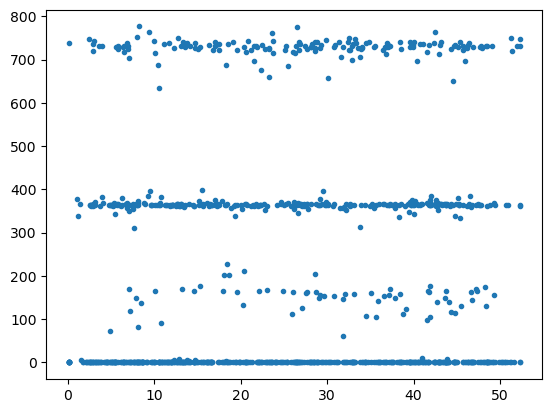

In [3]:
plt.plot(data.corrected_week,data.passive,'.')

In [4]:
data_pm25=pd.read_excel(r"../../Data_and_Preprocessing/pm25_BC_corrected.xlsx")


In [5]:
gpr_pm25=torch.load("../models/pm25_seasonality",weights_only=False,map_location='cuda')
gpr_bc=torch.load("../models/seasonality_BC",weights_only=False,map_location='cuda')
gpr_no2=torch.load("../models/no2_seasonality",weights_only=False,map_location='cuda')
gpr_nox=torch.load("../models/nox_seasonality",weights_only=False,map_location='cuda')
gpr_form=torch.load("../models/form_seasonality",weights_only=False,map_location='cuda')
gpr_acetald=torch.load("../models/acetald_seasonality",weights_only=False,map_location='cuda')
gpr_acetone=torch.load("../models/acetone_seasonality",weights_only=False,map_location='cuda')
gpr_vocs=torch.load("../models/acetone_seasonality",weights_only=False,map_location='cuda')

In [6]:
def scale_season(data,model):
    X=[]
    for i in data.corrected_week: 
        x=np.linspace(i-26.25,i,500)
        x1=np.where(x<0,52.5+x,x)
        theta=x1*2*np.pi/52.5
        sin=np.sin(theta)
        cos=np.sin(theta)
        periodic_data=pd.DataFrame(np.array([cos,sin]).T,columns=["x_cos","x_sin"])
        linmod=torch.from_numpy(periodic_data.values.astype("float64")).to(device)
        y=model(linmod)[0].cpu().detach().numpy()
        X.append(integrate.simpson(y)/(len(y)*y[-1]))
    return X

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
data

,Unnamed: 0.1,Unnamed: 0,corrected_week,gastove,passive,road,household,no2,nox,formaldehyd,acetald,acetone,label,Total_VOCs
0,0,0,20.709578,5.308982,363.278046,2662.474344,287,3.263104,14.335334,12.145404,5.917962,10.572000,1,28.635366
1,1,1,38.420623,358.375986,0.653069,19876.657790,25,7.987763,2.297266,16.314118,5.205600,4.236663,0,25.756381
2,2,2,42.067014,7.207379,385.157315,17576.292306,137,7.859245,29.790606,11.249104,4.624050,1.952602,0,17.825756
3,3,3,33.519814,2.913015,727.110287,13399.844713,134,6.931319,4.045385,12.659604,1.390792,0.937036,1,14.987433
4,4,4,5.492294,365.000000,0.000000,24088.105831,197,11.721324,2.997806,17.734909,5.769755,10.788594,0,34.293257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,960,960,26.762427,-0.216623,741.203065,18203.596337,324,5.702950,13.052886,22.550685,13.332018,16.701851,0,52.584553
961,961,961,23.083276,0.086748,362.434934,22343.201939,243,13.146825,6.579330,19.457870,6.640907,11.807791,0,37.906568
962,962,962,8.818219,2.601440,367.641225,17463.926923,234,5.772236,22.986123,NaN,NaN,7.531150,0,7.531150
963,963,963,35.055729,1.433844,161.443984,17113.806104,337,7.825932,10.342800,20.790917,6.057747,3.030491,0,29.879155


In [11]:
data_pm25["pm_scale"]=scale_season(data_pm25,gpr_pm25)
data_pm25["bc_scale"]=scale_season(data_pm25,gpr_bc)
data["no2_scale"]=scale_season(data,gpr_no2)
data["nox_scale"]=scale_season(data,gpr_nox)
data["form_scale"]=scale_season(data,gpr_form)
data["acetald_scale"]=scale_season(data,gpr_acetald)
data["acetone_scale"]=scale_season(data,gpr_acetone)
data["vocs_scale"]=scale_season(data,gpr_vocs)

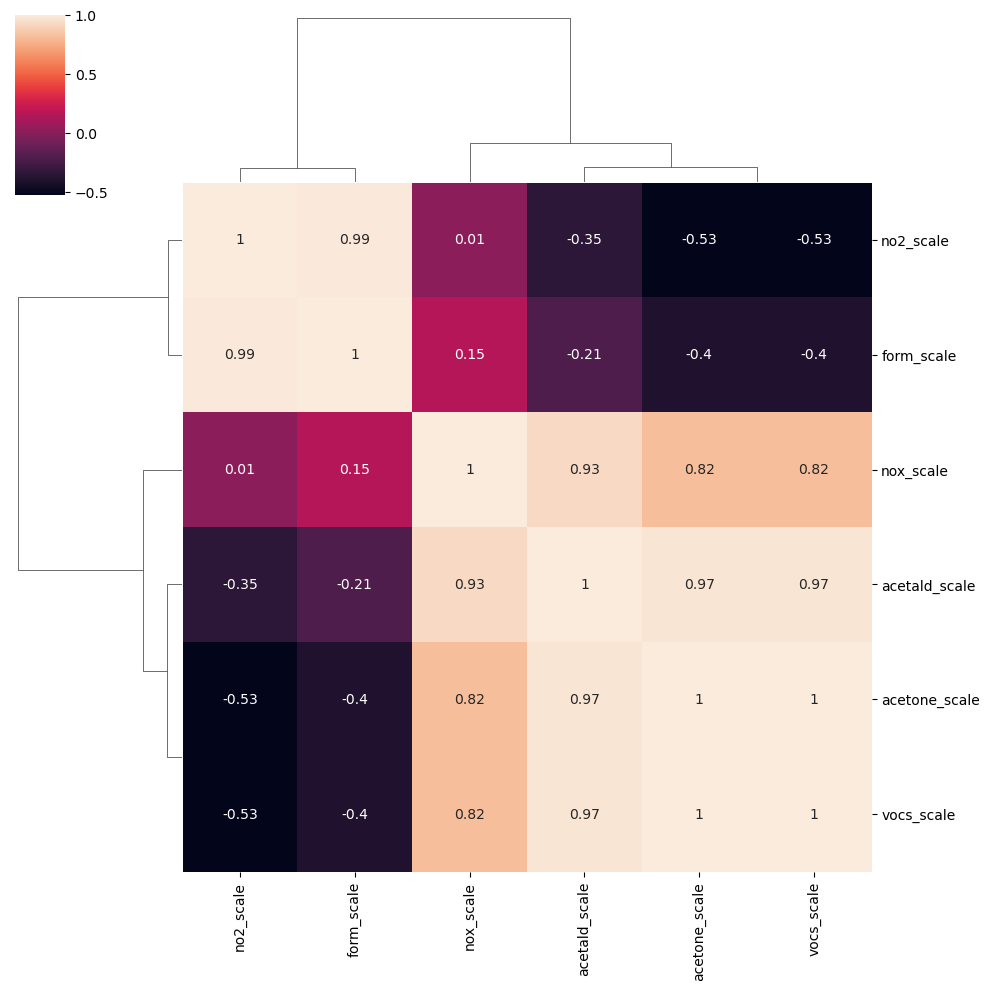

In [12]:
sns.clustermap(data.loc[:,['no2_scale', 'nox_scale', 'form_scale', 'acetald_scale',
       'acetone_scale','vocs_scale']].corr(),annot=True)

In [13]:
data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'corrected_week', 'gastove', 'passive',
       'road', 'household', 'no2', 'nox', 'formaldehyd', 'acetald', 'acetone',
       'label', 'Total_VOCs', 'no2_scale', 'nox_scale', 'form_scale',
       'acetald_scale', 'acetone_scale', 'vocs_scale'],
      dtype='object')

In [14]:
data_pm25["pm25_season"]=data_pm25.pm25_Gaussion*data_pm25.pm_scale
data_pm25["bc_season"]=data_pm25.BC_Gaussion*data_pm25.bc_scale
data["no2_season"]=data.no2*data.no2_scale
data["nox_season"]=data.nox*data.nox_scale
data["form_season"]=data.formaldehyd*data.form_scale
data["acetald_season"]=data.acetald*data.acetald_scale
data["acetone_season"]=data.acetone_scale*data.acetone
data["vocs_season"]=data.vocs_scale*data.Total_VOCs

In [18]:
data.to_excel("chemicals_scaled_values.xlsx")

In [19]:
data_pm25.to_excel("pm25_scaled_values.xlsx")